## 1 Packages

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

In [15]:
import sys
import importlib

# --- FIX: AUTORELOAD FOR JUPYTER ---
# These lines ensure that when you save changes to logistic_regression.py, 
# the notebook will automatically reload the new code.
%load_ext autoreload
%autoreload 2
# -----------------------------------

# Now importing DH_OBJ from the logistic_regression package
try:
    # 1. Check if the module is already loaded (cached)
    if 'logistic_regression' in sys.modules:
        print("Module 'logistic_regression' found in cache. Forcing reload...")
        importlib.reload(sys.modules['logistic_regression'])
    elif 'utils' in sys.modules:
        print("Module 'utils' found in cache. Forcing reload...")
        importlib.reload(sys.modules['utils'])
    
    # 2. Perform the import (this will use the reloaded or new version)
    from logistic_regression import LogisticRegression_lr
    import utils as ut
except ImportError as e:
    print(f"\n[ERROR] Import failed. Ensure your 'logistic_regression' folder and 'logistic_regression.py' are correctly structured.")
    print(f"Details: {e}")
    sys.exit(1)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Module 'logistic_regression' found in cache. Forcing reload...


In [16]:
# Set styles and seeds for reproducibility
plt.style.use('seaborn-v0_8')
sns.set_palette(sns.color_palette())
np.random.seed(42)
tf.random.set_seed(42)

## 2 Loading and data visualization

In [4]:
# Load the dataset
df = pd.read_excel("../data/Dry_Bean_Dataset.xlsx")

# Separate features and target (using all data)
X_full = df.drop(columns=['Class']).values # Use all 16 features
y_full = df['Class'].values # Use all 7 classes

# Encode the 7 class labels to integers (0 to 6)
label_encoder_full = LabelEncoder()
y_encoded_full = label_encoder_full.fit_transform(y_full)
num_classes = len(label_encoder_full.classes_)
target_names = label_encoder_full.classes_
input_shape = X_full.shape[1] # 16 features

print(f"Full dataset shape: {X_full.shape}")
print(f"Number of classes: {num_classes}")

# Split the full dataset (67% train, 16.5% CV, 16.5% test)
# This uses the same split ratios as the Logistic Regression notebooks
X_train_full, X_, y_train_full, y_ = train_test_split(
    X_full, y_encoded_full, test_size=0.33, random_state=42, stratify=y_encoded_full
)

X_cv_full, X_test_full, y_cv_full, y_test_full = train_test_split(
    X_, y_, test_size=0.5, random_state=42, stratify=y_
)

# Scale all 16 features
scaler_full = StandardScaler()
X_train_scaled = scaler_full.fit_transform(X_train_full)
X_cv_scaled = scaler_full.transform(X_cv_full)
X_test_scaled = scaler_full.transform(X_test_full)

# desired order
labels_desired_order = ['SEKER', 'BARBUNYA', 'BOMBAY', 'CALI', 'HOROZ', 'SIRA', 'DERMASON']

print(f"Train shapes: X={X_train_scaled.shape}, y={y_train_full.shape}")
print(f"CV shapes: X={X_cv_scaled.shape}, y={y_cv_full.shape}")
print(f"Test shapes: X={X_test_scaled.shape}, y={y_test_full.shape}")

# Convert y to one-hot for TensorFlow (categorical crossentropy)
y_train_onehot = tf.keras.utils.to_categorical(y_train_full, num_classes)
y_cv_onehot = tf.keras.utils.to_categorical(y_cv_full, num_classes)
y_test_onehot = tf.keras.utils.to_categorical(y_test_full, num_classes)

Full dataset shape: (13611, 16)
Number of classes: 7
Train shapes: X=(9119, 16), y=(9119,)
CV shapes: X=(2246, 16), y=(2246,)
Test shapes: X=(2246, 16), y=(2246,)


## 3 Model Definition (3 Layers with L2 Regularization)

In [17]:
# Define 3-layer neural network model with optional dropout\n
def create_model(input_size, hidden_layers, num_classes, reg=0.0, dropout_rate=0.0):
    model = Sequential()
    model.add(Input(shape=(input_size,)))
    for neurons in hidden_layers:
        model.add(Dense(neurons, activation='relu', kernel_regularizer=l2(reg)))
        if dropout_rate > 0:
            model.add(Dropout(dropout_rate))
    model.add(Dense(num_classes, activation='softmax', kernel_regularizer=l2(reg)))
    return model
# Default Hyperparameters for initial run
input_size = X_full.shape[1]  # 16 features
hidden_layers = [128, 64]
learning_rate = 0.001
num_epochs = 100
batch_size = 6

## 4 Training

In [19]:
# Train the model with EarlyStopping
model = create_model(input_size, hidden_layers, num_classes)
optimizer = Adam(learning_rate=learning_rate)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=10, 
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    X_train_scaled, y_train_onehot,
    validation_data=(X_cv_scaled, y_cv_onehot),
    epochs=num_epochs,
    batch_size=batch_size,
    callbacks=[early_stop],
    verbose=1
)

print("\\nModel Summary:")
model.summary()

Epoch 1/100
1520/1520 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8968 - loss: 0.3104 - val_accuracy: 0.9207 - val_loss: 0.2150
Epoch 2/100
1520/1520 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9235 - loss: 0.2144 - val_accuracy: 0.9230 - val_loss: 0.2059
Epoch 3/100
1520/1520 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9263 - loss: 0.2055 - val_accuracy: 0.9225 - val_loss: 0.2005
Epoch 4/100
1520/1520 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9269 - loss: 0.1998 - val_accuracy: 0.9194 - val_loss: 0.1978
Epoch 5/100
1520/1520 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9292 - loss: 0.1956 - val_accuracy: 0.9207 - val_loss: 0.1995
Epoch 6/100
1520/1520 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9295 - loss: 0.1929 - val_accuracy: 0.9230 - val_loss: 0.1944
Epoch 7/100
1520/1520 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9312 - loss: 0.1889 - val_accuracy: 0.9230 - val_loss: 0.1955
Epoch 8/100
1520/1520 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9319 - loss: 0

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 128)            │         2,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,663 (127.59 KB)

 Trainable params: 10,887 (42.53 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 21,776 (85.07 KB)

## 5 Evaluation and plotting

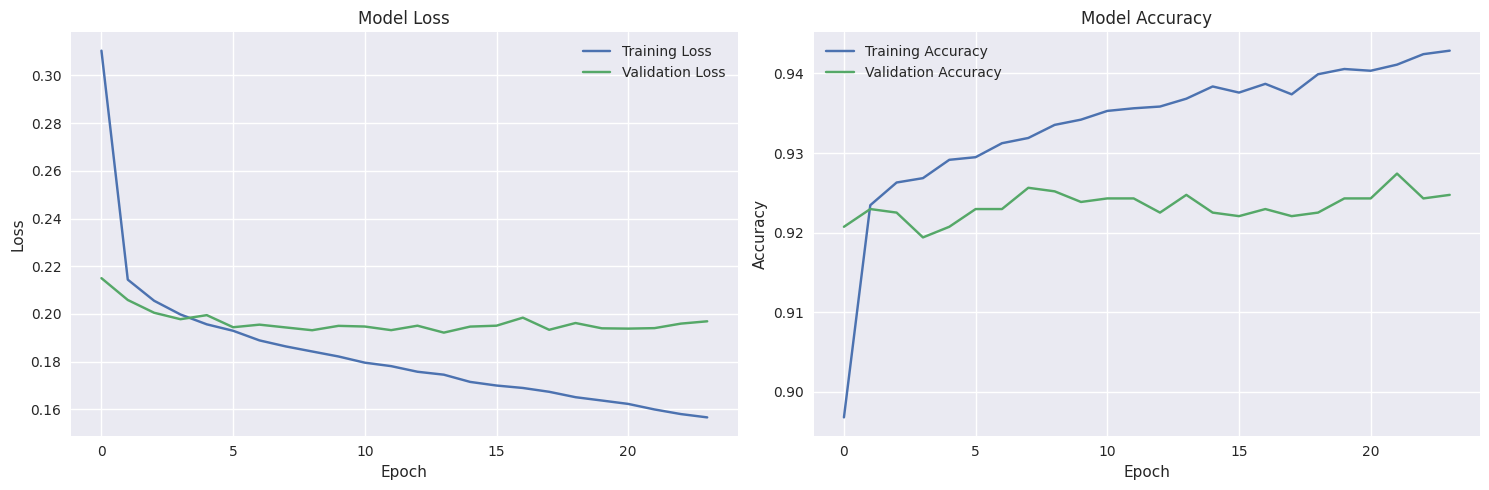

In [20]:
# Plot training history (Loss and Accuracy)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Loss
ax1.plot(history.history['loss'], label='Training Loss')
ax1.plot(history.history['val_loss'], label='Validation Loss')
ax1.set_title('Model Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

# Accuracy
ax2.plot(history.history['accuracy'], label='Training Accuracy')
ax2.plot(history.history['val_accuracy'], label='Validation Accuracy')
ax2.set_title('Model Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

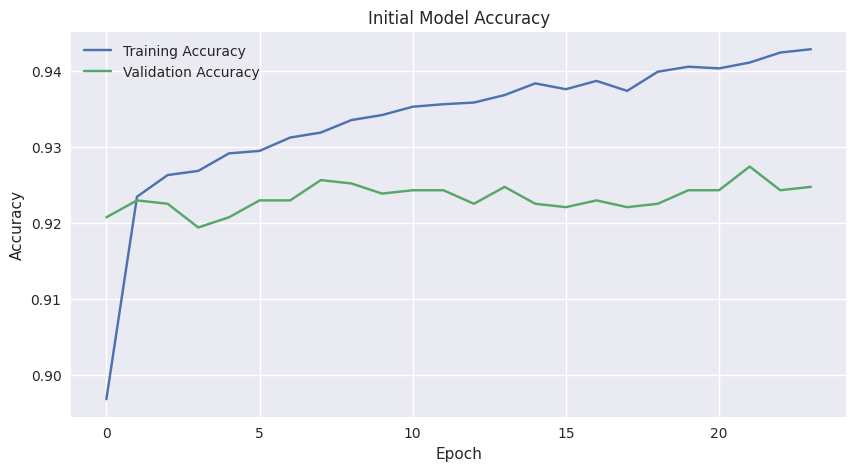

In [21]:
# Plot training history (Accuracy only)
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Initial Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

## 6 Hyperparameter Regularization

In [ ]:
# Systematic Hyperparameter Tuning
print('--- Systematic Hyperparameter Tuning ---')

tuning_results = []

# Define the search space
architectures = [
    [64, 32],        # Small
    [128, 64],       # Medium (original)
    [256, 128, 64]   # Large/Deep
]
learning_rates = [0.001, 0.0005]
dropout_rates = [0.0, 0.1, 0.2]
l2_regs = [1e-4, 1e-3]

best_val_acc = 0
best_params = {}

for layers in architectures:
    for lr in learning_rates:
        for dropout in dropout_rates:
            for reg in l2_regs:
                print(f'Testing: Layers={layers}, LR={lr}, Dropout={dropout}, L2={reg}')
                
                model = create_model(input_size, layers, num_classes, reg=reg, dropout_rate=dropout)
                optimizer = Adam(learning_rate=lr)
                model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
                
                early_stop_tune = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=0)
                
                history = model.fit(
                    X_train_scaled, y_train_onehot,
                    validation_data=(X_cv_scaled, y_cv_onehot),
                    epochs=50, # Shorter epochs for tuning
                    batch_size=batch_size,
                    callbacks=[early_stop_tune],
                    verbose=0
                )
                
                val_loss, val_acc = model.evaluate(X_cv_scaled, y_cv_onehot, verbose=0)
                
                tuning_results.append({
                    'layers': layers,
                    'lr': lr,
                    'dropout': dropout,
                    'reg': reg,
                    'val_acc': val_acc
                })
                
                if val_acc > best_val_acc:
                    best_val_acc = val_acc
                    best_params = {
                        'layers': layers,
                        'lr': lr,
                        'dropout': dropout,
                        'reg': reg
                    }
                    print(f'  --> New Best Val Acc: {val_acc:.4f}')

print('--- Tuning Complete ---')
print(f'Best Parameters: {best_params}')
print(f'Best Validation Accuracy: {best_val_acc:.4f}')

\n--- Systematic Hyperparameter Tuning ---
Testing: Layers=[64, 32], LR=0.001, Dropout=0.0, L2=0.0001
  --> New Best Val Acc: 0.9292
Testing: Layers=[64, 32], LR=0.001, Dropout=0.0, L2=0.001
Testing: Layers=[64, 32], LR=0.001, Dropout=0.1, L2=0.0001
Testing: Layers=[64, 32], LR=0.001, Dropout=0.1, L2=0.001
Testing: Layers=[64, 32], LR=0.001, Dropout=0.2, L2=0.0001
  --> New Best Val Acc: 0.9301
Testing: Layers=[64, 32], LR=0.001, Dropout=0.2, L2=0.001
Testing: Layers=[64, 32], LR=0.0005, Dropout=0.0, L2=0.0001
Testing: Layers=[64, 32], LR=0.0005, Dropout=0.0, L2=0.001
Testing: Layers=[64, 32], LR=0.0005, Dropout=0.1, L2=0.0001
Testing: Layers=[64, 32], LR=0.0005, Dropout=0.1, L2=0.001
Testing: Layers=[64, 32], LR=0.0005, Dropout=0.2, L2=0.0001
Testing: Layers=[64, 32], LR=0.0005, Dropout=0.2, L2=0.001
Testing: Layers=[128, 64], LR=0.001, Dropout=0.0, L2=0.0001
Testing: Layers=[128, 64], LR=0.001, Dropout=0.0, L2=0.001
Testing: Layers=[128, 64], LR=0.001, Dropout=0.1, L2=0.0001
Testing:

In [23]:
# Retrain the final model with best parameters and more epochs
print('Retraining final model with best parameters...')
model = create_model(
    input_size, 
    best_params['layers'], 
    num_classes, 
    reg=best_params['reg'], 
    dropout_rate=best_params['dropout']
)

optimizer = Adam(learning_rate=best_params['lr'])
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

early_stop_final = EarlyStopping(
    monitor='val_loss', 
    patience=15, 
    restore_best_weights=True, 
    verbose=1
)

history_final = model.fit(
    X_train_scaled, y_train_onehot,
    validation_data=(X_cv_scaled, y_cv_onehot),
    epochs=150,
    batch_size=batch_size,
    callbacks=[early_stop_final],
    verbose=0
)
print('Final model training complete.')

\nRetraining final model with best parameters...
Epoch 37: early stopping
Restoring model weights from the end of the best epoch: 22.
Final model training complete.


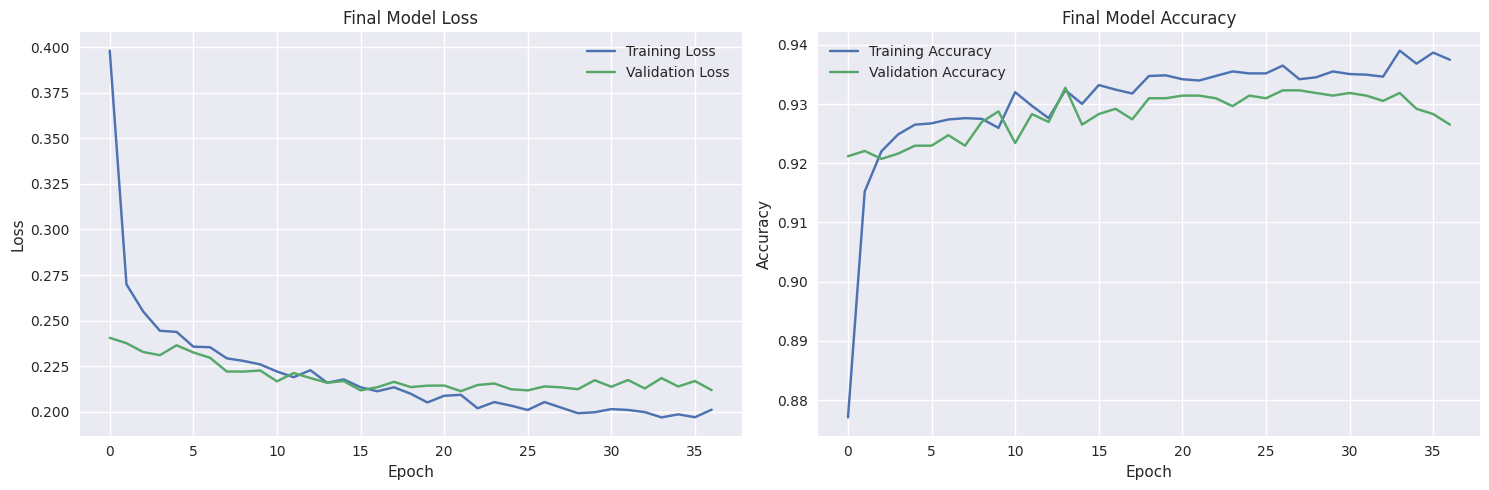

Final Test Accuracy: 0.9283
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


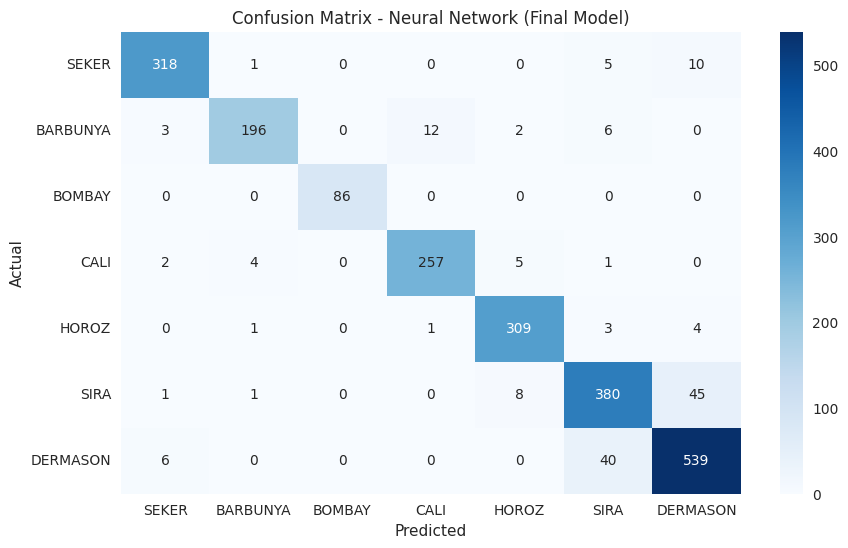

In [25]:
# Plot final training history (Loss and Accuracy)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Loss
ax1.plot(history_final.history['loss'], label='Training Loss')
ax1.plot(history_final.history['val_loss'], label='Validation Loss')
ax1.set_title('Final Model Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

# Accuracy
ax2.plot(history_final.history['accuracy'], label='Training Accuracy')
ax2.plot(history_final.history['val_accuracy'], label='Validation Accuracy')
ax2.set_title('Final Model Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

# Final test accuracy
test_loss, test_acc = model.evaluate(X_test_scaled, y_test_onehot, verbose=0)
print(f'Final Test Accuracy: {test_acc:.4f}')

# 6. Plot confusion matrix
y_test_pred = np.argmax(model.predict(X_test_scaled), axis=1)
cm = confusion_matrix(y_test_full, y_test_pred, labels=label_encoder_full.transform(labels_desired_order))
conf_df = pd.DataFrame(
    cm,
    index=labels_desired_order, 
    columns=labels_desired_order
)

plt.figure(figsize=(10, 6))
sns.heatmap(conf_df, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_desired_order,
            yticklabels=labels_desired_order,)
plt.title('Confusion Matrix - Neural Network (Final Model)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
# Classification Report
print("Classification Report (Test Data):")
report = classification_report(y_test_full, y_test_pred, target_names=labels_desired_order, output_dict=True)
ut.classification_report_to_file(report, "nn_tuned")

print(classification_report(y_test_full, y_test_pred, target_names=labels_desired_order))


Classification Report (Test Data):


NameError: name 'classification_report' is not defined